# Histopathologic Cancer Detection — Image EDA

## A · Setup

In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
CLR_IMG = {0: '#2ecc71', 1: '#e74c3c'}

IMG_DIR   = '/kaggle/input/competitions/histopathologic-cancer-detection/train'
LABEL_CSV = '/kaggle/input/competitions/histopathologic-cancer-detection/train_labels.csv'

labels_df = pd.read_csv(LABEL_CSV)
labels_df['path'] = labels_df['id'].apply(lambda x: os.path.join(IMG_DIR, x + '.tif'))
print(f'Total images : {len(labels_df):,}')
print(f'Normal  (0)  : {(labels_df.label==0).sum():,}  ({(labels_df.label==0).mean()*100:.1f}%)')
print(f'Tumor   (1)  : {(labels_df.label==1).sum():,}  ({(labels_df.label==1).mean()*100:.1f}%)')
labels_df.head()

Total images : 220,025
Normal  (0)  : 130,908  (59.5%)
Tumor   (1)  : 89,117  (40.5%)


,id,label,path
0,f38a6374c348f90b587e046aac6079959adf3835,0,/kaggle/input/competitions/histopathologic-can...
1,c18f2d887b7ae4f6742ee445113fa1aef383ed77,1,/kaggle/input/competitions/histopathologic-can...
2,755db6279dae599ebb4d39a9123cce439965282d,0,/kaggle/input/competitions/histopathologic-can...
3,bc3f0c64fb968ff4a8bd33af6971ecae77c75e08,0,/kaggle/input/competitions/histopathologic-can...
4,068aba587a4950175d04c680d38943fd488d6a9d,0,/kaggle/input/competitions/histopathologic-can...


## B · Sample Images (Normal vs Tumor)

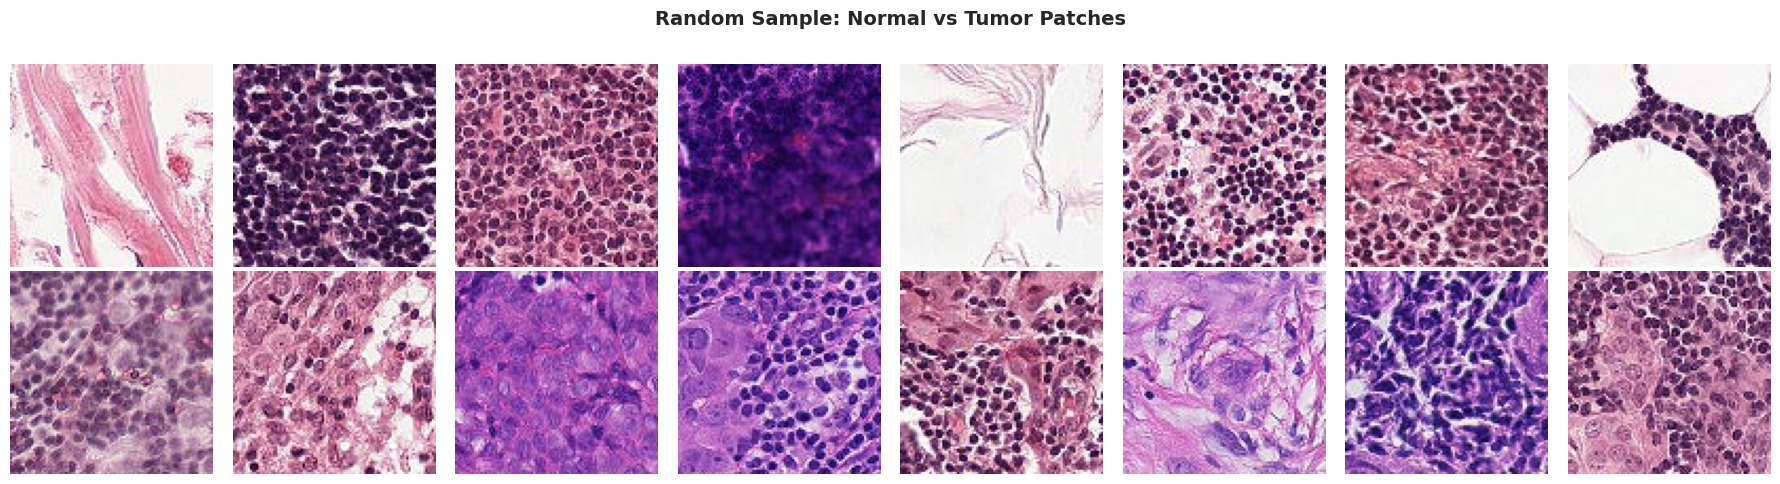

In [12]:
N_SHOW = 8
normal_paths = labels_df[labels_df.label == 0]['path'].sample(N_SHOW, random_state=42).values
tumor_paths  = labels_df[labels_df.label == 1]['path'].sample(N_SHOW, random_state=42).values

fig, axes = plt.subplots(2, N_SHOW, figsize=(18, 5))
for i, (npath, tpath) in enumerate(zip(normal_paths, tumor_paths)):
    axes[0, i].imshow(Image.open(npath))
    axes[0, i].axis('off')
    axes[1, i].imshow(Image.open(tpath))
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Normal', fontsize=12, color=CLR_IMG[0], fontweight='bold')
axes[1, 0].set_ylabel('Tumor',  fontsize=12, color=CLR_IMG[1], fontweight='bold')
fig.suptitle('Random Sample: Normal vs Tumor Patches', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## C · Image Size & Channel Check

In [13]:
# Check a sample of 500 images for size consistency and channel count
sample_paths = labels_df['path'].sample(500, random_state=0).values
sizes, channels = [], []
for p in sample_paths:
    img = np.array(Image.open(p))
    sizes.append(img.shape[:2])
    channels.append(img.shape[2] if img.ndim == 3 else 1)

unique_sizes = pd.Series(sizes).value_counts()
unique_chans = pd.Series(channels).value_counts()
print('Image sizes found:')
print(unique_sizes.to_string())
print(f'\nChannels: {unique_chans.to_dict()}')

Image sizes found:
(96, 96)    500

Channels: {3: 500}


## D · Mean RGB per Class

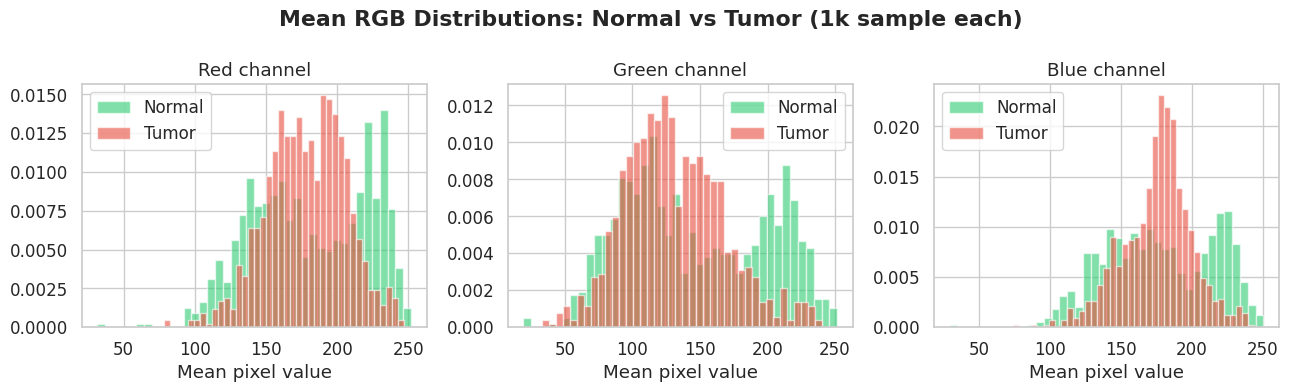

Normal   — R: 181.1  G: 146.6  B: 177.7
Tumor    — R: 177.9  G: 130.4  B: 175.7


In [14]:
SAMPLE_N = 1000  # images per class
mean_rgb = {0: [], 1: []}

for lbl in [0, 1]:
    paths = labels_df[labels_df.label == lbl]['path'].sample(SAMPLE_N, random_state=42).values
    for p in paths:
        img = np.array(Image.open(p)).astype(np.float32)
        mean_rgb[lbl].append(img.mean(axis=(0, 1)))  # shape (3,)

mean_rgb = {k: np.array(v) for k, v in mean_rgb.items()}

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
channel_names = ['Red', 'Green', 'Blue']
for ch, (ax, ch_name) in enumerate(zip(axes, channel_names)):
    for lbl, label_name, color in [(0, 'Normal', CLR_IMG[0]), (1, 'Tumor', CLR_IMG[1])]:
        ax.hist(mean_rgb[lbl][:, ch], bins=40, alpha=0.6, color=color, label=label_name, density=True)
    ax.set_title(f'{ch_name} channel')
    ax.set_xlabel('Mean pixel value')
    ax.legend()

fig.suptitle('Mean RGB Distributions: Normal vs Tumor (1k sample each)', fontweight='bold')
plt.tight_layout()
plt.show()

for lbl, name in [(0, 'Normal'), (1, 'Tumor')]:
    r, g, b = mean_rgb[lbl].mean(axis=0)
    print(f'{name:8s} — R: {r:.1f}  G: {g:.1f}  B: {b:.1f}')

## E · Pixel Brightness Distribution (Grayscale)

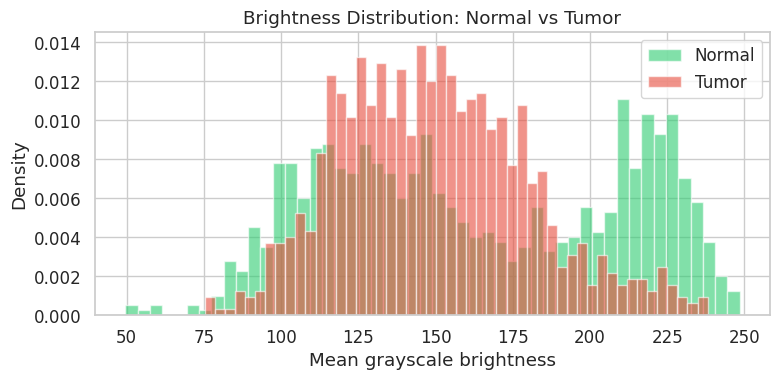

In [15]:
brightness = {0: [], 1: []}

for lbl in [0, 1]:
    paths = labels_df[labels_df.label == lbl]['path'].sample(SAMPLE_N, random_state=7).values
    for p in paths:
        img = np.array(Image.open(p).convert('L')).astype(np.float32)
        brightness[lbl].append(img.mean())

fig, ax = plt.subplots(figsize=(8, 4))
for lbl, label_name, color in [(0, 'Normal', CLR_IMG[0]), (1, 'Tumor', CLR_IMG[1])]:
    ax.hist(brightness[lbl], bins=50, alpha=0.6, color=color, label=label_name, density=True)
ax.set_xlabel('Mean grayscale brightness')
ax.set_ylabel('Density')
ax.set_title('Brightness Distribution: Normal vs Tumor')
ax.legend()
plt.tight_layout()
plt.show()

## F · Mean Image per Class

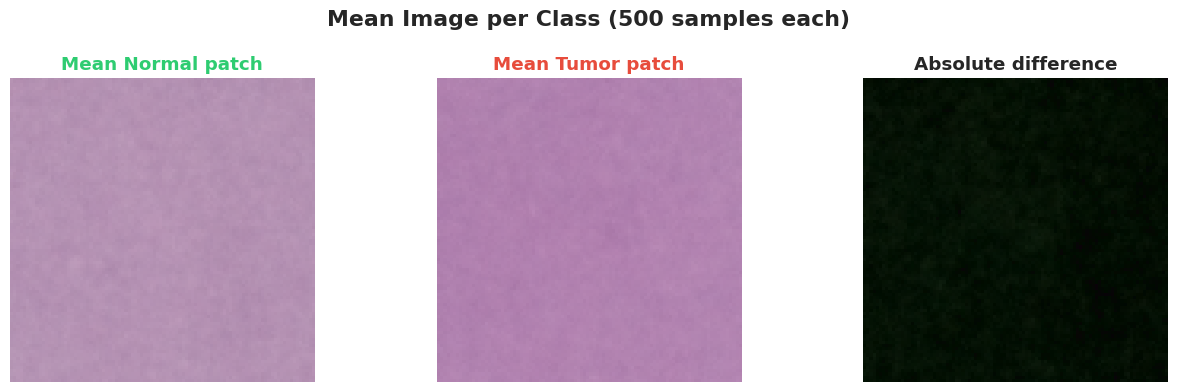

In [16]:
MEAN_N = 500
mean_imgs = {}

for lbl in [0, 1]:
    paths = labels_df[labels_df.label == lbl]['path'].sample(MEAN_N, random_state=99).values
    stack = np.stack([np.array(Image.open(p)).astype(np.float32) for p in paths])
    mean_imgs[lbl] = stack.mean(axis=0).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(mean_imgs[0])
axes[0].set_title('Mean Normal patch', color=CLR_IMG[0], fontweight='bold')
axes[0].axis('off')

axes[1].imshow(mean_imgs[1])
axes[1].set_title('Mean Tumor patch', color=CLR_IMG[1], fontweight='bold')
axes[1].axis('off')

diff = np.abs(mean_imgs[1].astype(int) - mean_imgs[0].astype(int)).astype(np.uint8)
axes[2].imshow(diff)
axes[2].set_title('Absolute difference', fontweight='bold')
axes[2].axis('off')

fig.suptitle(f'Mean Image per Class ({MEAN_N} samples each)', fontweight='bold')
plt.tight_layout()
plt.show()

## G · Class Balance (Images)

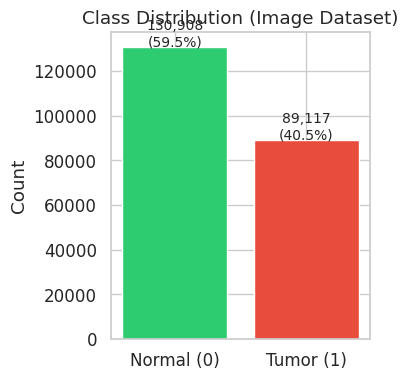

In [17]:
counts = labels_df['label'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(4, 4))
ax.bar(['Normal (0)', 'Tumor (1)'], counts.values,
       color=[CLR_IMG[0], CLR_IMG[1]], edgecolor='white')
for i, v in enumerate(counts.values):
    ax.text(i, v + 300, f'{v:,}\n({v/len(labels_df)*100:.1f}%)', ha='center', fontsize=10)
ax.set_ylabel('Count')
ax.set_title('Class Distribution (Image Dataset)')
plt.tight_layout()
plt.show()

---
# Histopathologic Cancer Detection — Features EDA

## 1 · Imports

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)

FEATURE_GROUPS = {
    'DoG Blob':  (0,  11),
    'Color HSV': (11, 17),
    'GLCM':      (17, 22),
    'LBP':       (22, 32),
    'LBGLCM':    (32, 37),
    'GLRLM':     (37, 42),
    'SFTA':      (42, 51),
}

CLR = {0: '#2ecc71', 1: '#e74c3c'}
print('Imports OK')

Imports OK


## 2 · Load Data

In [19]:
NPZ_PATH = '/kaggle/input/notebooks/amr2054/feature-extraction/extracted_features_dog_color_glcm_lbp_lbglcm_glrlm_sfta.npz'

data = np.load(NPZ_PATH, allow_pickle=True)
X = data['X'].astype(np.float64)
y = data['Y'].astype(int)

N, D = X.shape
feat_names = [f'f{i}' for i in range(D)]
df = pd.DataFrame(X, columns=feat_names)
df.insert(0, 'label', y)

print(f'Shape      : {X.shape}')
print(f'Normal (0) : {(y==0).sum():,}  ({(y==0).mean()*100:.1f}%)')
print(f'Tumor  (1) : {(y==1).sum():,}  ({(y==1).mean()*100:.1f}%)')
print(f'NaNs       : {np.isnan(X).sum()}')
print(f'Infs       : {np.isinf(X).sum()}')
df.describe().T.round(3)

Shape      : (220025, 51)
Normal (0) : 130,908  (59.5%)
Tumor  (1) : 89,117  (40.5%)
NaNs       : 0
Infs       : 0


,count,mean,std,min,25%,50%,75%,max
label,220025.0,0.405,0.491,0.000,0.000,0.000,1.000,1.000
f0,220025.0,32.088,24.925,0.000,10.000,28.000,51.000,124.000
f1,220025.0,3.161,1.213,0.000,2.871,3.017,3.386,18.536
f2,220025.0,1.041,1.244,0.000,0.256,0.617,1.317,7.854
f3,220025.0,45.929,16.985,0.000,46.629,51.629,53.877,134.350
f4,220025.0,6.219,8.763,0.000,3.162,4.472,6.325,134.350
f5,220025.0,21.411,8.644,0.000,22.517,24.274,25.319,58.050
f6,220025.0,198.536,52.926,0.000,194.357,209.706,224.129,255.000
f7,220025.0,23.835,12.590,0.000,15.452,26.192,33.219,101.000
f8,220025.0,135.580,59.625,0.000,102.000,134.000,178.000,255.000


## 3 · Class Balance (Features)

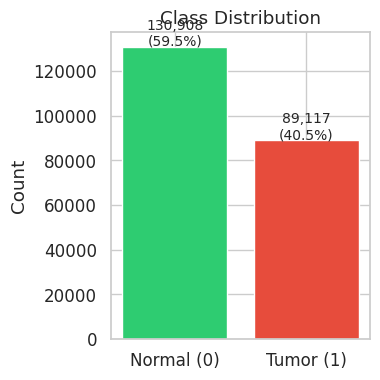

In [20]:
counts = pd.Series(y).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(4, 4))
ax.bar(['Normal (0)', 'Tumor (1)'], counts.values,
       color=[CLR[0], CLR[1]], edgecolor='white')
for i, v in enumerate(counts.values):
    ax.text(i, v + 500, f'{v:,}\n({v/N*100:.1f}%)', ha='center', fontsize=10)
ax.set_ylabel('Count')
ax.set_title('Class Distribution')
plt.tight_layout()
plt.show()

## 4 · Feature Distributions by Group

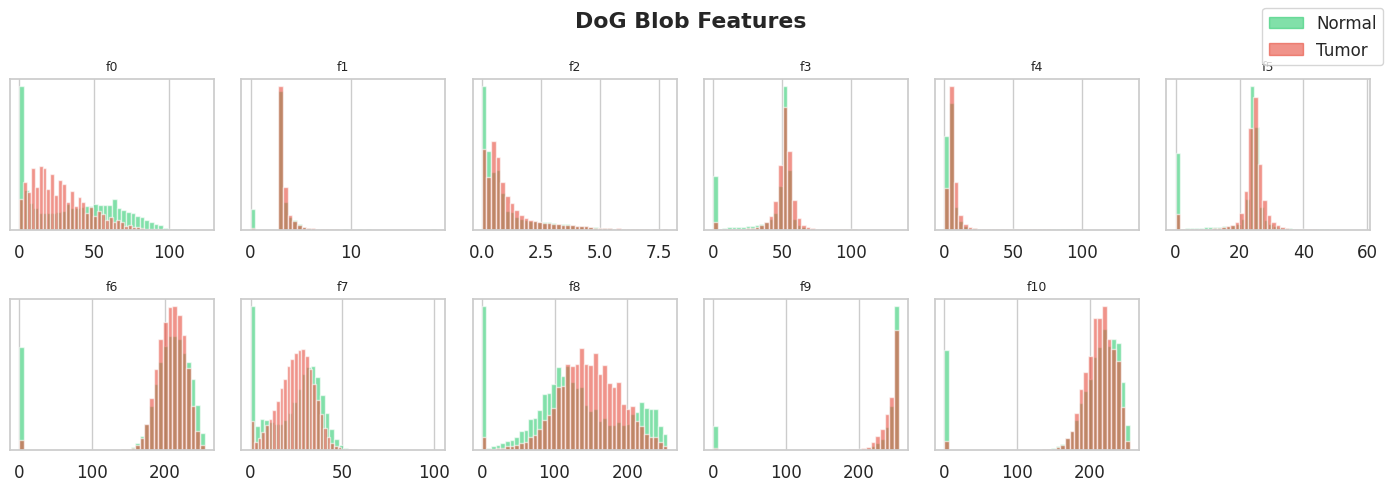

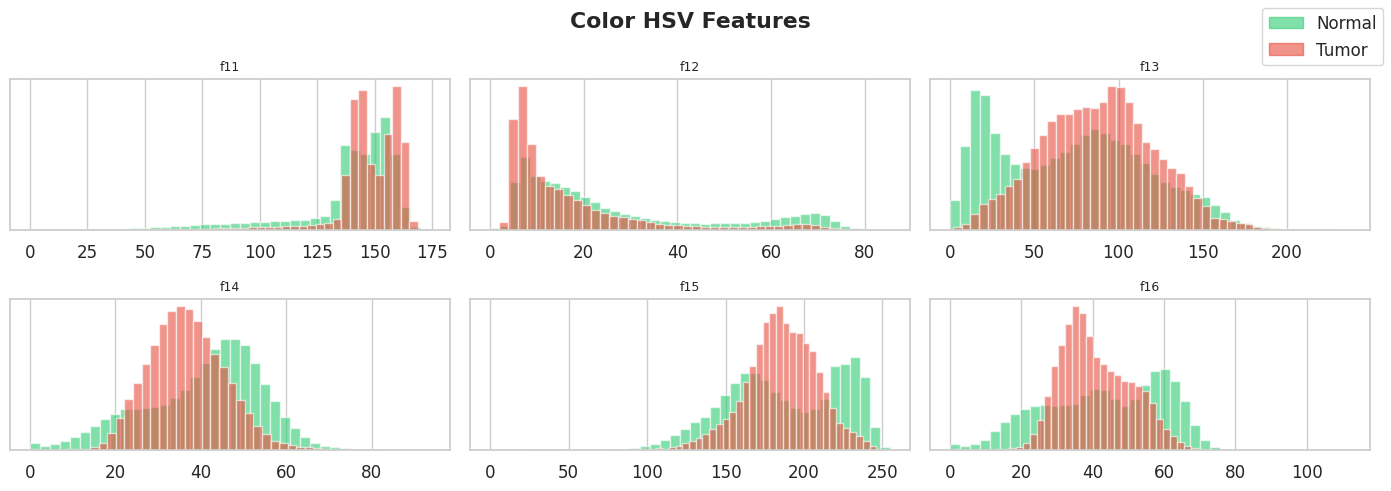

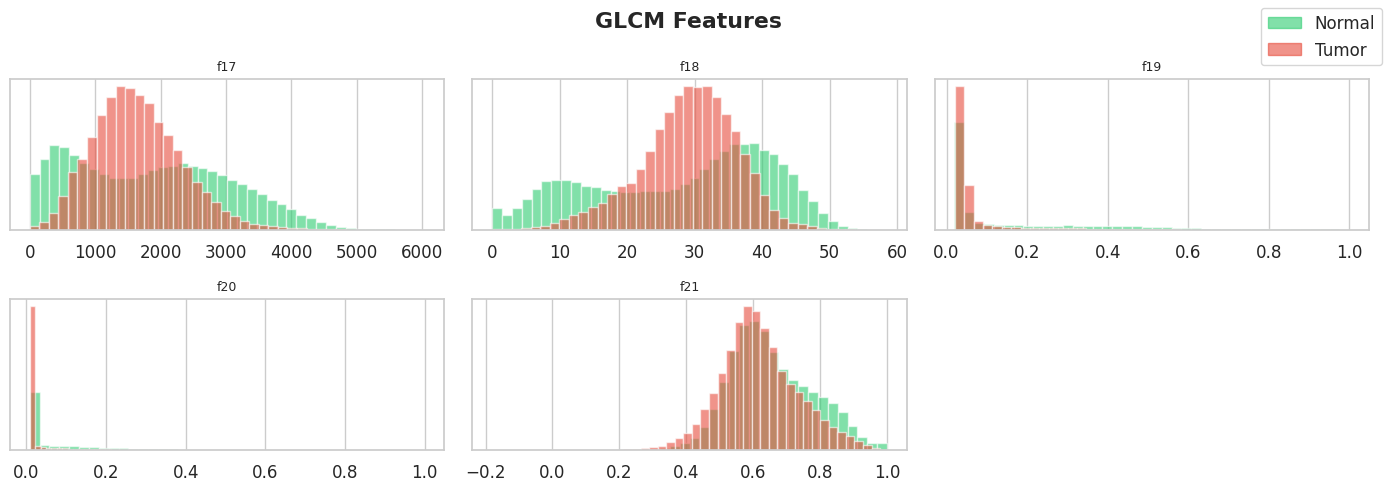

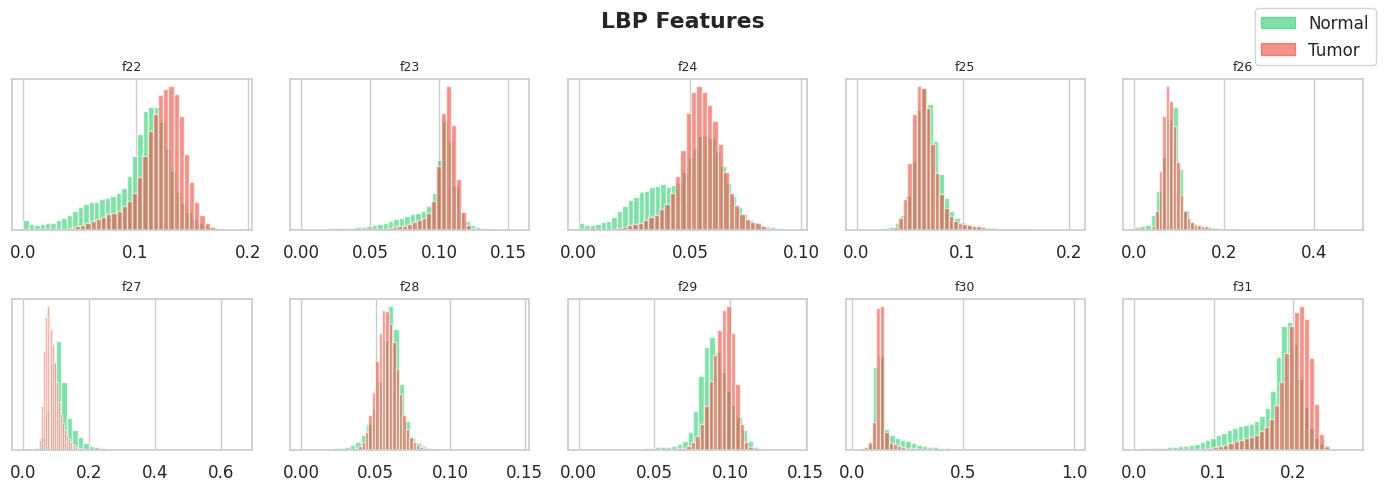

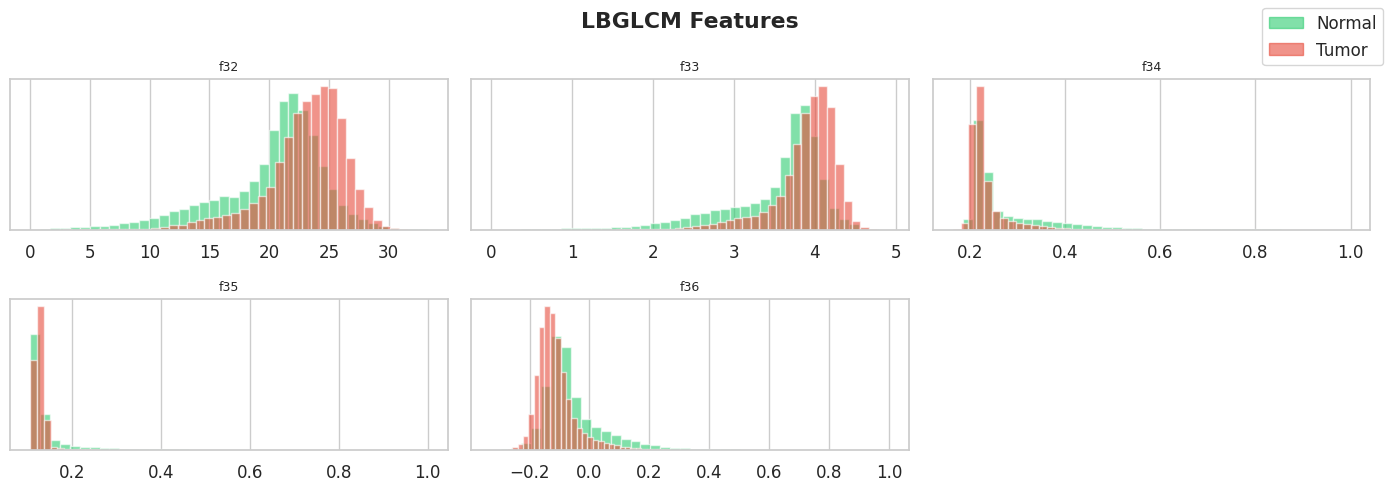

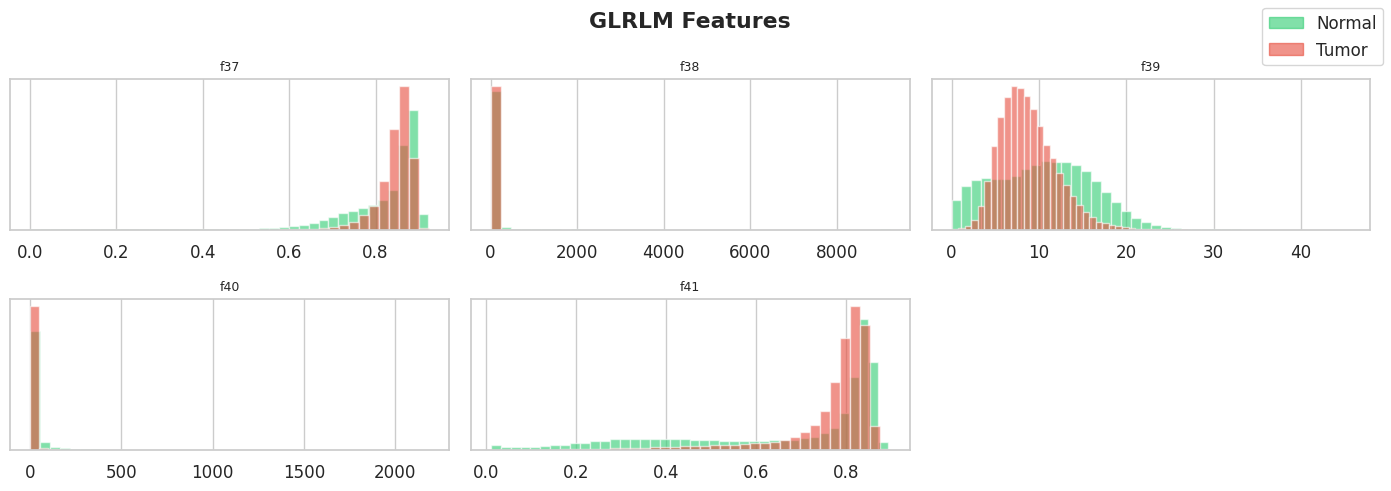

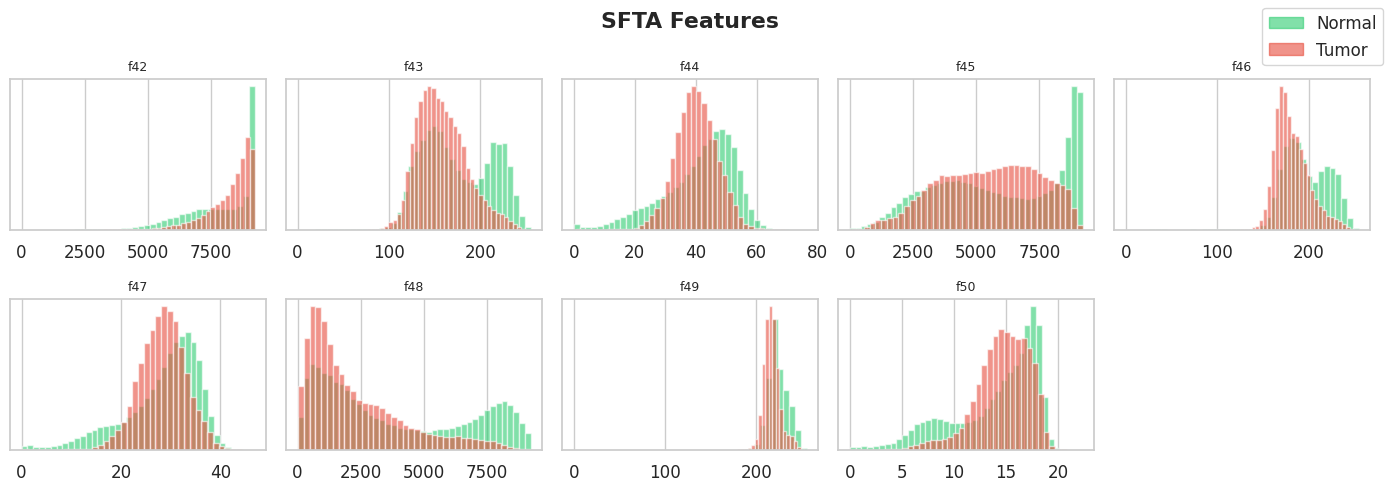

In [21]:
for group, (start, end) in FEATURE_GROUPS.items():
    cols = feat_names[start:end]
    n_cols = len(cols)
    fig, axes = plt.subplots(2, (n_cols + 1) // 2, figsize=(14, 5))
    axes = axes.flatten()
    for ax, col in zip(axes, cols):
        for lbl, color in CLR.items():
            subset = df.loc[df['label'] == lbl, col]
            ax.hist(subset, bins=40, alpha=0.6, color=color,
                    label='Normal' if lbl == 0 else 'Tumor', density=True)
        ax.set_title(col, fontsize=9)
        ax.set_yticks([])
    # hide unused subplots
    for ax in axes[n_cols:]:
        ax.set_visible(False)
    handles = [plt.Rectangle((0,0),1,1, color=CLR[0], alpha=0.6),
               plt.Rectangle((0,0),1,1, color=CLR[1], alpha=0.6)]
    fig.legend(handles, ['Normal', 'Tumor'], loc='upper right')
    fig.suptitle(f'{group} Features', fontweight='bold')
    plt.tight_layout()
    plt.show()

## 5 · Correlation Heatmap

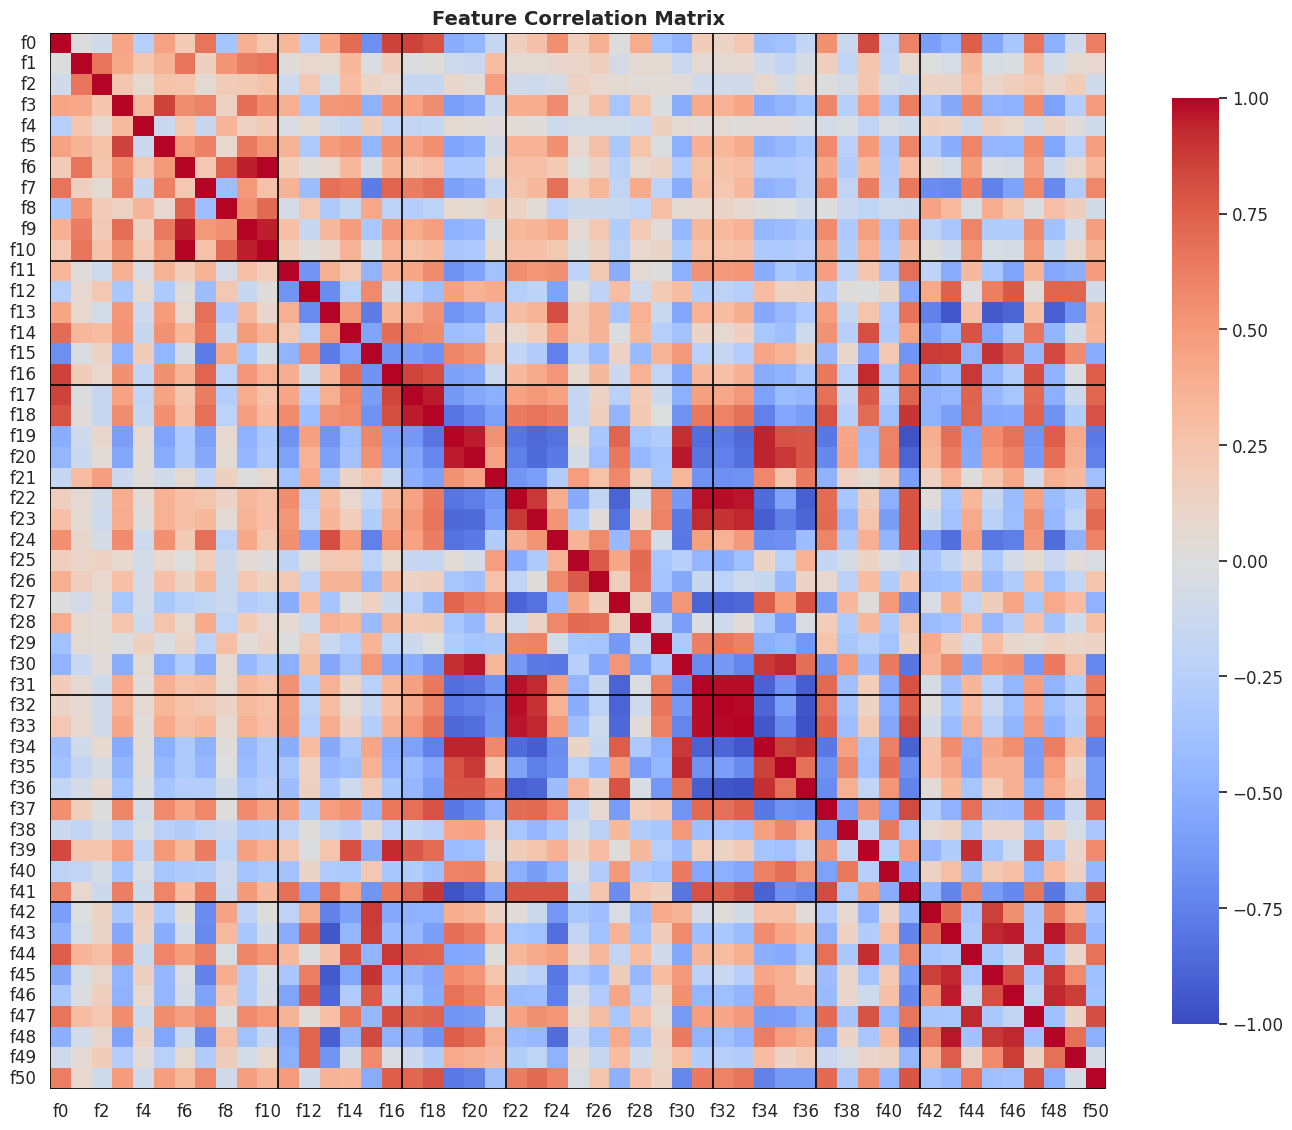

Pairs with |corr| > 0.90: 39


,f1,f2,corr
288,f6,f10,0.995668
1104,f32,f33,0.984854
878,f22,f32,0.983134
1085,f31,f32,0.978844
1086,f31,f33,0.978312
877,f22,f31,0.973956
1124,f33,f36,0.969970
879,f22,f33,0.965153
800,f19,f41,0.964871
1251,f43,f48,0.963390


In [22]:
corr = df[feat_names].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0, ax=ax, cbar_kws={'shrink': 0.8})

# draw group boundary lines
boundaries = [0] + [end for _, (_, end) in FEATURE_GROUPS.items()]
for b in boundaries:
    ax.axhline(b, color='black', lw=1.2)
    ax.axvline(b, color='black', lw=1.2)

ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# highly correlated pairs
high_corr = (
    corr.abs()
    .where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .reset_index()
    .rename(columns={'level_0': 'f1', 'level_1': 'f2', 0: 'corr'})
    .query('corr > 0.90')
    .sort_values('corr', ascending=False)
)
print(f'Pairs with |corr| > 0.90: {len(high_corr)}')
high_corr.head(10)

## 6 · Feature–Label Correlation (Separability)

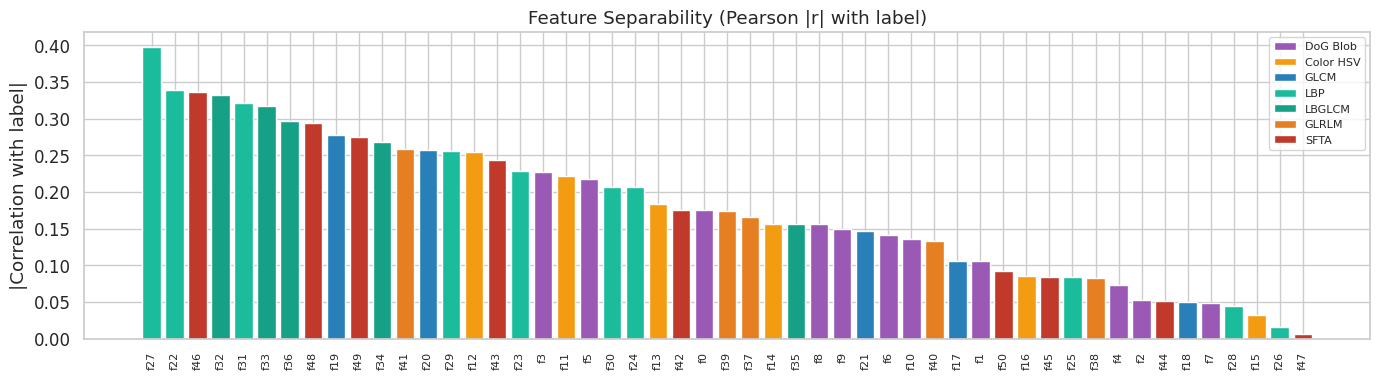

Top 10 most separating features:
f27    0.398439
f22    0.338943
f46    0.336849
f32    0.332133
f31    0.320967
f33    0.317292
f36    0.296686
f48    0.293880
f19    0.277833
f49    0.274730


In [23]:
label_corr = df[feat_names].corrwith(df['label']).abs().sort_values(ascending=False)

# color bars by group
group_color_map = {
    'DoG Blob': '#9b59b6', 'Color HSV': '#f39c12', 'GLCM': '#2980b9',
    'LBP': '#1abc9c', 'LBGLCM': '#16a085', 'GLRLM': '#e67e22', 'SFTA': '#c0392b'
}
def feat_to_color(fname):
    idx = int(fname[1:])
    for grp, (s, e) in FEATURE_GROUPS.items():
        if s <= idx < e:
            return group_color_map[grp]
    return 'gray'

colors = [feat_to_color(f) for f in label_corr.index]

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(len(label_corr)), label_corr.values, color=colors)
ax.set_xticks(range(len(label_corr)))
ax.set_xticklabels(label_corr.index, rotation=90, fontsize=8)
ax.set_ylabel('|Correlation with label|')
ax.set_title('Feature Separability (Pearson |r| with label)')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=g) for g, c in group_color_map.items()]
ax.legend(handles=legend_elements, loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

print('Top 10 most separating features:')
print(label_corr.head(10).to_string())

## 7 · PCA (2 Components)

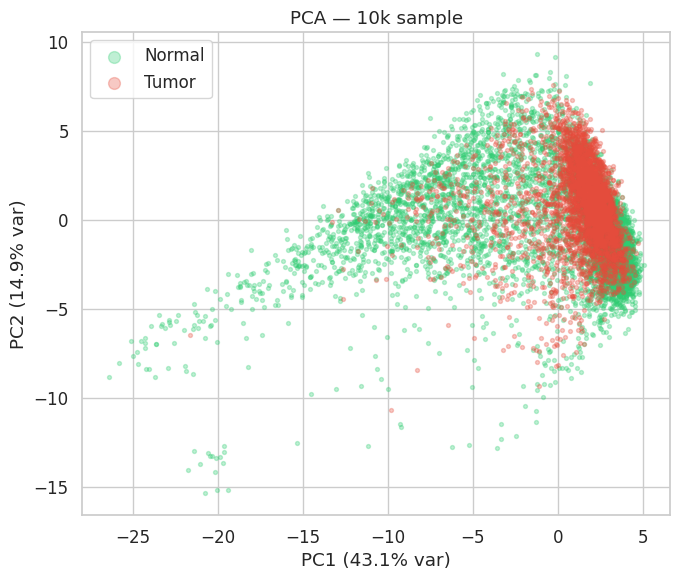

In [27]:
# subsample for speed
IDX = np.random.choice(N, size=10_000, replace=False)
X_sub = X[IDX]
y_sub = y[IDX]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sub)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(7, 6))
for lbl, label_name, color in [(0, 'Normal', CLR[0]), (1, 'Tumor', CLR[1])]:
    mask = y_sub == lbl
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=color, label=label_name, alpha=0.3, s=8, rasterized=True)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title('PCA — 10k sample')
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()

## 8 · Outlier Check (features beyond 3σ)

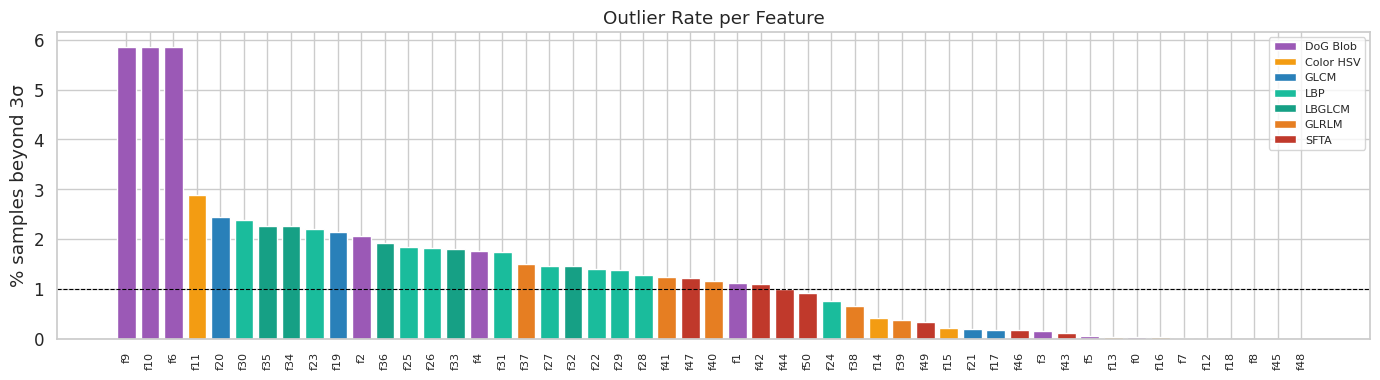

Features with >1% outliers:
f9     5.862970
f10    5.862970
f6     5.862970
f11    2.883309
f20    2.437905
f30    2.385184
f35    2.262925
f34    2.252926
f23    2.193387
f19    2.149301
f2     2.064311
f36    1.910692
f25    1.838882
f26    1.822975
f33    1.800704
f4     1.756619
f31    1.745256
f37    1.498466
f27    1.453017
f32    1.449835
f22    1.387570
f29    1.377116
f28    1.274855
f41    1.236678
f47    1.222588
f40    1.158505
f1     1.108965
f42    1.098966


In [24]:
means = df[feat_names].mean()
stds  = df[feat_names].std()
outlier_pct = (((df[feat_names] - means).abs() > 3 * stds).sum() / N * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 4))
colors = [feat_to_color(f) for f in outlier_pct.index]
ax.bar(range(len(outlier_pct)), outlier_pct.values, color=colors)
ax.axhline(1, color='black', linestyle='--', linewidth=0.8, label='1% threshold')
ax.set_xticks(range(len(outlier_pct)))
ax.set_xticklabels(outlier_pct.index, rotation=90, fontsize=8)
ax.set_ylabel('% samples beyond 3σ')
ax.set_title('Outlier Rate per Feature')
legend_elements = [plt.matplotlib.patches.Patch(facecolor=c, label=g) for g, c in group_color_map.items()]
ax.legend(handles=legend_elements, loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

print('Features with >1% outliers:')
print(outlier_pct[outlier_pct > 1].to_string())

## 9 · Per-Group Mean Comparison (Normal vs Tumor)

In [25]:
group_means = df.groupby('label')[feat_names].mean().T
group_means.columns = ['Normal (0)', 'Tumor (1)']
group_means['diff_%'] = ((group_means['Tumor (1)'] - group_means['Normal (0)']) / (group_means['Normal (0)'].abs() + 1e-9) * 100).round(1)
group_means = group_means.sort_values('diff_%', key=abs, ascending=False)

print('Top 15 features by relative mean difference (Normal vs Tumor):')
group_means.head(15).style.background_gradient(subset=['diff_%'], cmap='RdYlGn', vmin=-100, vmax=100).format({'Normal (0)': '{:.3f}', 'Tumor (1)': '{:.3f}', 'diff_%': '{:.1f}%'})

Top 15 features by relative mean difference (Normal vs Tumor):


,Normal (0),Tumor (1),diff_%
f36,-0.057,-0.114,-99.8%
f38,81.672,8.336,-89.8%
f40,39.495,4.300,-89.1%
f20,0.062,0.022,-65.1%
f19,0.161,0.068,-58.0%
f48,3840.427,2256.115,-41.3%
f12,26.643,16.529,-38.0%
f0,35.704,26.778,-25.0%
f27,0.113,0.086,-23.7%
f4,5.693,6.991,22.8%


This table shows how much each of the 51 features changes on average between Normal and Tumor patches. The **`diff_%`** value captures this relative change, where large positive values mean the feature is higher in tumor tissue, large negative values mean it is lower, and values near zero indicate little difference between the two. Features from **GLRLM**, **SFTA**, and **GLCM** generally appear at the top, suggesting they better capture the differences between healthy and cancerous tissue.

## 10 · Near-Zero Variance Check

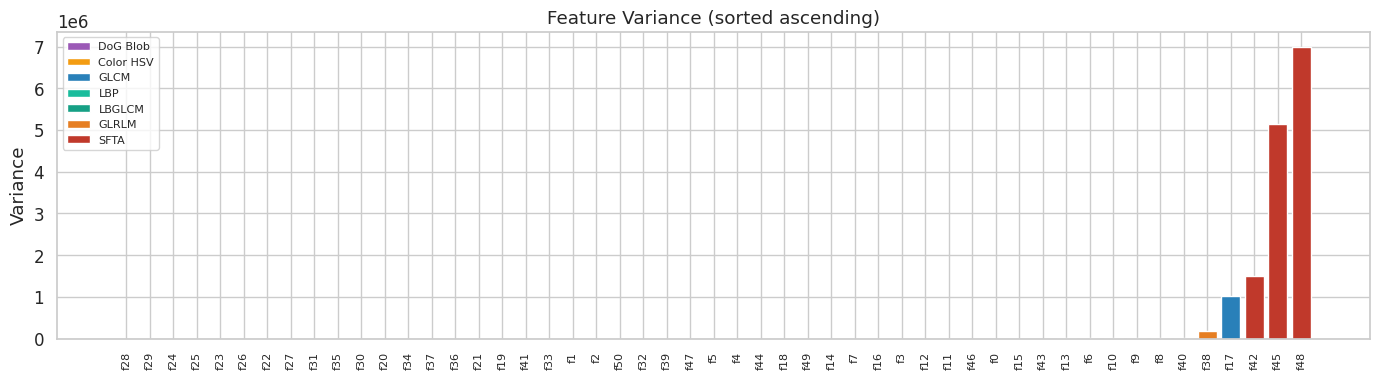

Bottom 10% lowest-variance features (5 features):
f28    0.000074
f29    0.000119
f24    0.000212
f25    0.000218
f23    0.000270


In [26]:
variances = df[feat_names].var().sort_values()
low_var = variances[variances < variances.quantile(0.10)]

fig, ax = plt.subplots(figsize=(14, 4))
colors_var = [feat_to_color(f) for f in variances.index]
ax.bar(range(len(variances)), variances.values, color=colors_var)
ax.set_xticks(range(len(variances)))
ax.set_xticklabels(variances.index, rotation=90, fontsize=8)
ax.set_ylabel('Variance')
ax.set_title('Feature Variance (sorted ascending)')
legend_elements = [plt.matplotlib.patches.Patch(facecolor=c, label=g) for g, c in group_color_map.items()]
ax.legend(handles=legend_elements, loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

print(f'Bottom 10% lowest-variance features ({len(low_var)} features):')
print(low_var.round(6).to_string())

This plot ranks all 51 features by their variance across the dataset, from lowest to highest. Features with near-zero variance are almost constant and don’t add useful information, so they can be removed before training. The lowest 10% are especially safe to drop, while features with very high variance may need scaling or outlier handling. Along with the correlated features identified earlier, this helps guide feature selection by removing weak features and reducing redundancy.

## Conclusion

| | Finding |
|---|---|
| **Class Balance** | ~60/40 split — healthy enough to train without resampling |
| **Visual Signal** | Tumor patches are visibly pinker and denser; color and brightness shift consistently across the dataset |
| **Best Features** | GLCM, GLRLM, and SFTA features separate the classes most clearly — confirmed by both correlation (EDA #6) and mean shift (EDA #9) |
| **Redundancy** | Several features are near-duplicates of each other — worth pruning before training |
| **Weak Features** | A handful of features barely vary across images at all (EDA #10) — can be dropped |
| **Outliers** | A few features have heavy tails (EDA #8) — to be scaled robustly or capped before training |
| **PCA** | Classes overlap in 2D, meaning the signal is spread across many dimensions — linear models will struggle, tree-based ones won't |